In [3]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, confusion_matrix, classification_report

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# File Paths Configuration
FILES = {
    "predictions": r"C:\research_projects\video_analysis_pipeline_research\results\processing_results_filtered.json",
    "gt_topics": r"C:\research_projects\video_analysis_pipeline_research\data\annotations_videos\video\cleaned_result\video_Topics_clean.json",
    "gt_sentiments": r"C:\research_projects\video_analysis_pipeline_research\data\annotations_videos\video\cleaned_result\video_Sentiments_clean.json",
    "gt_funny": r"C:\research_projects\video_analysis_pipeline_research\data\annotations_videos\video\cleaned_result\video_Funny_clean.json",
    "gt_exciting": r"C:\research_projects\video_analysis_pipeline_research\data\annotations_videos\video\cleaned_result\video_Exciting_clean.json",
    "gt_effective": r"C:\research_projects\video_analysis_pipeline_research\data\annotations_videos\video\cleaned_result\video_Effective_clean.json"
}

In [4]:
def load_json(path):
    if not os.path.exists(path):
        print(f"[WARNING] File not found: {path}")
        return {}
    with open(path, 'r') as f:
        return json.load(f)

# Load all datasets
preds_raw = load_json(FILES["predictions"])
gt_topics = load_json(FILES["gt_topics"])
gt_sentiments = load_json(FILES["gt_sentiments"])
gt_funny = load_json(FILES["gt_funny"])
gt_exciting = load_json(FILES["gt_exciting"])
gt_effective = load_json(FILES["gt_effective"])

print(f"Loaded {len(preds_raw.get('results', []))} predictions.")

Loaded 1343 predictions.


In [5]:
data_rows = []

for item in preds_raw.get("results", []):
    # Extract Video ID (remove .mp4 extension)
    video_name = item.get("video_name", "")
    vid_id = os.path.splitext(video_name)[0]
    
    # Extract Predictions
    extract = item.get("extraction", {})
    pred_topic = extract.get("topic", {}).get("topic_id")
    pred_sentiment = extract.get("sentiment", {}).get("primary_sentiment_id")
    
    metrics = extract.get("engagement_metrics", {})
    pred_funny = metrics.get("is_funny")
    pred_exciting = metrics.get("is_exciting")
    pred_effective = metrics.get("effectiveness_score")

    row = {
        "video_id": vid_id,
        # Topics
        "pred_topic": int(pred_topic) if pred_topic is not None else None,
        "gt_topic": int(gt_topics.get(vid_id)) if vid_id in gt_topics else None,
        # Sentiments
        "pred_sentiment": int(pred_sentiment) if pred_sentiment is not None else None,
        "gt_sentiment": int(gt_sentiments.get(vid_id)) if vid_id in gt_sentiments else None,
        # Funny
        "pred_funny_score": float(pred_funny) if pred_funny is not None else None,
        "gt_funny_score": float(gt_funny.get(vid_id)) if vid_id in gt_funny else None,
        # Exciting
        "pred_exciting_score": float(pred_exciting) if pred_exciting is not None else None,
        "gt_exciting_score": float(gt_exciting.get(vid_id)) if vid_id in gt_exciting else None,
        # Effective
        "pred_effective": float(pred_effective) if pred_effective is not None else None,
        "gt_effective": float(gt_effective.get(vid_id)) if vid_id in gt_effective else None,
    }
    data_rows.append(row)

df = pd.DataFrame(data_rows)
df.set_index("video_id", inplace=True)

# Display first few rows
df.head()

,pred_topic,gt_topic,pred_sentiment,gt_sentiment,pred_funny_score,gt_funny_score,pred_exciting_score,gt_exciting_score,pred_effective,gt_effective
video_id,,,,,,,,,,
-1yXdOufzKE,25.0,25,8.0,5,0.0,0.2,0.3,1.0,4.0,5.0
-DFuMqROFCQ,8.0,8,23.0,4,0.1,0.2,0.2,0.6,5.0,3.0
-5X2kzIDroA,18.0,18,21.0,25,0.0,0.0,0.2,0.6,5.0,3.0
-HWd3Nqu8_0,21.0,21,1.0,5,0.2,0.2,0.9,1.0,4.0,3.0
-5zYYZpuTbU,21.0,21,1.0,5,0.0,0.2,0.9,0.6,4.0,4.0


In [6]:
def evaluate_classification(df, category_name, pred_col, gt_col):
    # Filter rows where we have both GT and Prediction
    subset = df.dropna(subset=[pred_col, gt_col])
    
    acc = accuracy_score(subset[gt_col], subset[pred_col])
    print(f"=== {category_name.upper()} EVALUATION ===")
    print(f"Evaluated samples: {len(subset)}")
    print(f"Top-1 Accuracy:    {acc:.2%}")
    
    # Optional: Detailed report (comment out if too verbose)
    print("\nClassification Report (Weighted Avg):")
    print(classification_report(subset[gt_col], subset[pred_col], zero_division=0, output_dict=False))

evaluate_classification(df, "Topic", "pred_topic", "gt_topic")
print("-" * 60)
evaluate_classification(df, "Sentiment", "pred_sentiment", "gt_sentiment")

=== TOPIC EVALUATION ===
Evaluated samples: 1288
Top-1 Accuracy:    86.96%

Classification Report (Weighted Avg):
              precision    recall  f1-score   support

           1       0.90      0.92      0.91        51
           2       0.95      0.94      0.94        64
           3       0.89      0.83      0.86        58
           4       0.71      0.71      0.71        14
           5       1.00      1.00      1.00         4
           6       0.92      1.00      0.96        34
           7       0.96      0.92      0.94        26
           8       0.95      0.91      0.93        90
           9       0.93      0.91      0.92        78
          10       0.98      0.71      0.82        79
          11       0.44      0.88      0.58         8
          12       0.90      0.93      0.91        28
          13       0.73      0.80      0.76        10
          14       0.50      0.50      0.50         2
          15       0.65      0.81      0.72        27
          16       0.

=== FUNNY EVALUATION ===
Regression MSE:      0.0678
Binary Accuracy:     87.69% (Clean GT only)
Binary Sample Size:  902 (out of 1288 total)


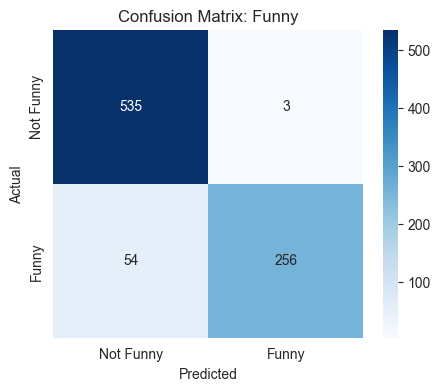

=== EXCITING EVALUATION ===
Regression MSE:      0.0598
Binary Accuracy:     69.04% (Clean GT only)
Binary Sample Size:  617 (out of 1288 total)


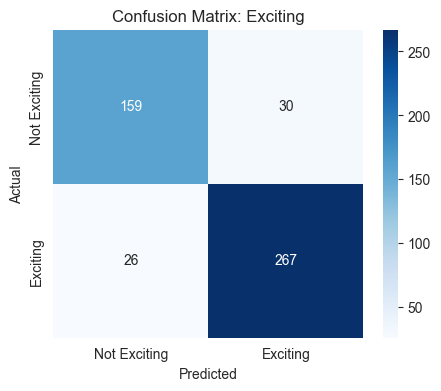

In [7]:
def get_binary_label(val, high=0.7, low=0.3):
    if val >= high: return 1
    if val <= low: return 0
    return -1 # Ambiguous

def evaluate_engagement(df, metric_name, pred_col, gt_col):
    subset = df.dropna(subset=[pred_col, gt_col]).copy()
    
    # 1. Regression Metrics
    mse = mean_squared_error(subset[gt_col], subset[pred_col])
    
    # 2. Binary Metrics
    # Convert GT and Preds to binary based on thresholds
    subset['gt_binary'] = subset[gt_col].apply(lambda x: get_binary_label(x))
    subset['pred_binary'] = subset[pred_col].apply(lambda x: get_binary_label(x))
    
    # Filter out Ambiguous Ground Truths for accuracy check
    binary_subset = subset[subset['gt_binary'] != -1]
    
    bin_acc = accuracy_score(binary_subset['gt_binary'], binary_subset['pred_binary'])
    
    print(f"=== {metric_name.upper()} EVALUATION ===")
    print(f"Regression MSE:      {mse:.4f}")
    print(f"Binary Accuracy:     {bin_acc:.2%} (Clean GT only)")
    print(f"Binary Sample Size:  {len(binary_subset)} (out of {len(subset)} total)")
    
    # Visualization: Confusion Matrix
    cm = confusion_matrix(binary_subset['gt_binary'], binary_subset['pred_binary'], labels=[0, 1])
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Not '+metric_name, metric_name], 
                yticklabels=['Not '+metric_name, metric_name])
    plt.title(f'Confusion Matrix: {metric_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

evaluate_engagement(df, "Funny", "pred_funny_score", "gt_funny_score")
evaluate_engagement(df, "Exciting", "pred_exciting_score", "gt_exciting_score")

=== EFFECTIVENESS EVALUATION ===
Mean Absolute Error (MAE): 1.0761 (on 1-5 scale)
Mean Squared Error (MSE):  1.9379


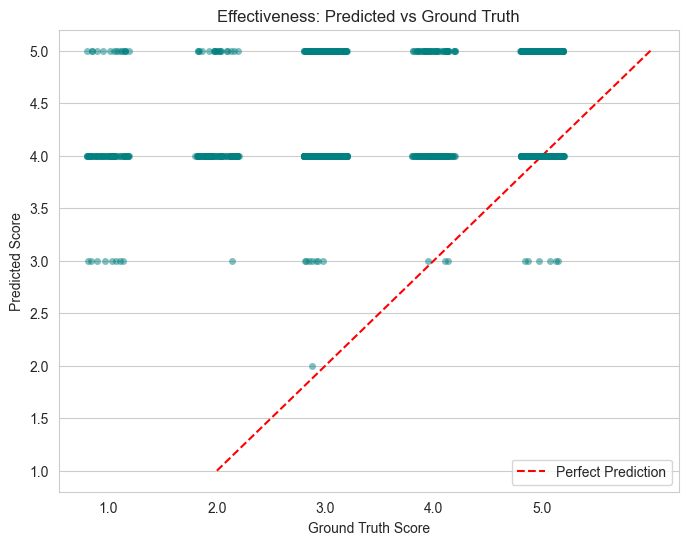

In [8]:
subset_eff = df.dropna(subset=['pred_effective', 'gt_effective'])

mae = mean_absolute_error(subset_eff['gt_effective'], subset_eff['pred_effective'])
mse = mean_squared_error(subset_eff['gt_effective'], subset_eff['pred_effective'])

print("=== EFFECTIVENESS EVALUATION ===")
print(f"Mean Absolute Error (MAE): {mae:.4f} (on 1-5 scale)")
print(f"Mean Squared Error (MSE):  {mse:.4f}")

# Visualization: Scatter plot with jitter to see density
plt.figure(figsize=(8, 6))
sns.stripplot(x=subset_eff['gt_effective'], y=subset_eff['pred_effective'], 
              alpha=0.5, jitter=0.2, color="teal")
plt.plot([1, 5], [1, 5], 'r--', label='Perfect Prediction')
plt.title("Effectiveness: Predicted vs Ground Truth")
plt.xlabel("Ground Truth Score")
plt.ylabel("Predicted Score")
plt.legend()
plt.show()

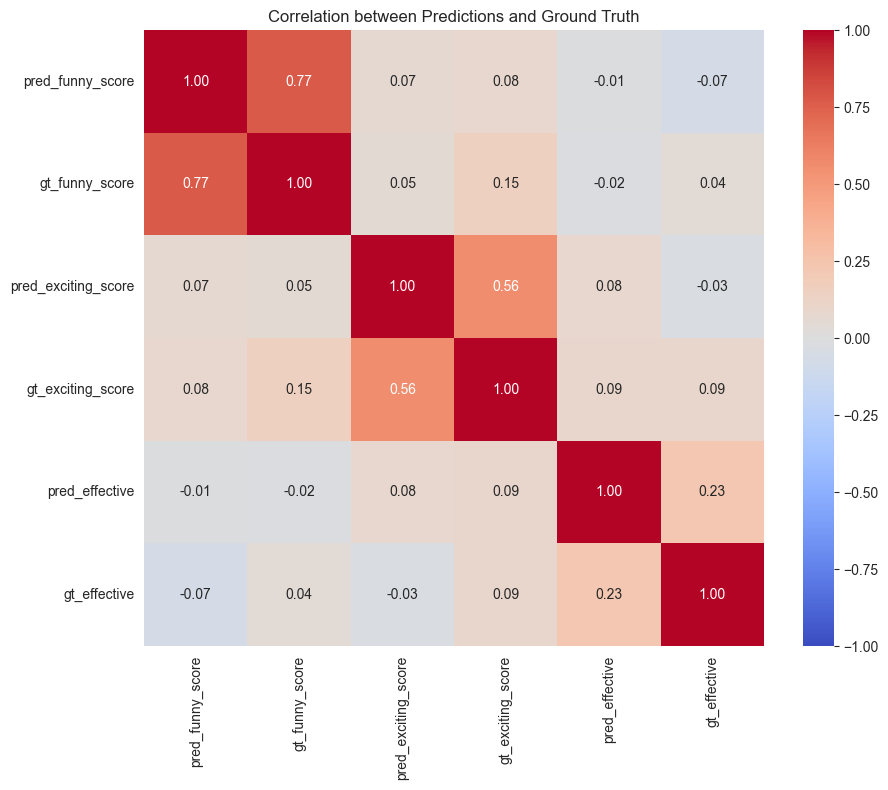

In [9]:
# Select only numeric columns of interest
corr_cols = [
    'pred_funny_score', 'gt_funny_score',
    'pred_exciting_score', 'gt_exciting_score',
    'pred_effective', 'gt_effective'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation between Predictions and Ground Truth")
plt.show()

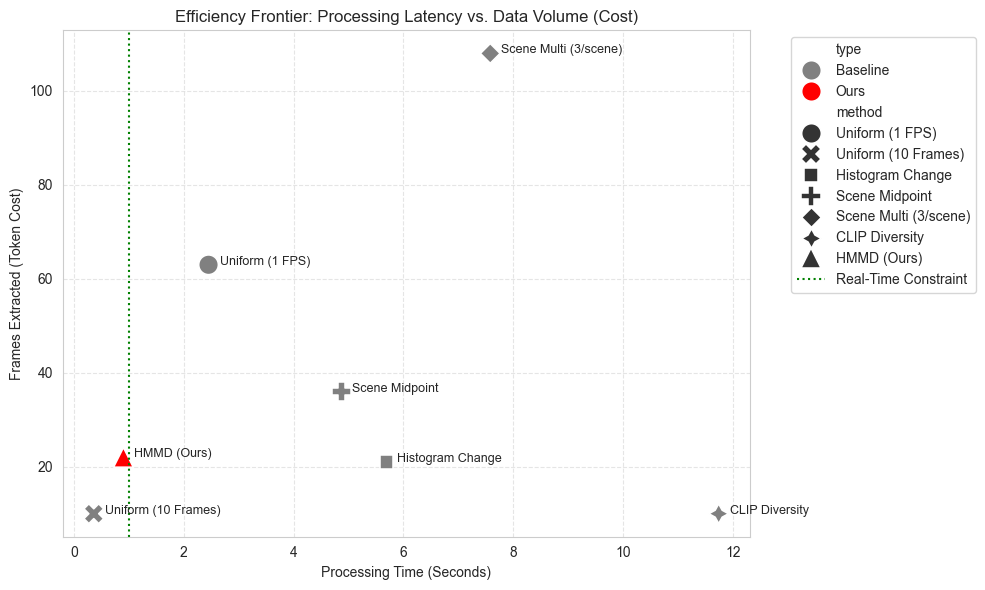

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Data from your log
data = [
    {"method": "Uniform (1 FPS)", "frames": 63, "time": 2.45, "type": "Baseline"},
    {"method": "Uniform (10 Frames)", "frames": 10, "time": 0.36, "type": "Baseline"},
    {"method": "Histogram Change", "frames": 21, "time": 5.69, "type": "Baseline"},
    {"method": "Scene Midpoint", "frames": 36, "time": 4.87, "type": "Baseline"},
    {"method": "Scene Multi (3/scene)", "frames": 108, "time": 7.58, "type": "Baseline"},
    {"method": "CLIP Diversity", "frames": 10, "time": 11.74, "type": "Baseline"},
    # Your HMMD Result (Averaged from previous batch for similar duration)
    {"method": "HMMD (Ours)", "frames": 22, "time": 0.9, "type": "Ours"} 
]

df = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="time", y="frames", hue="type", style="method", s=200, palette={"Baseline": "grey", "Ours": "red"})

# Annotate points
for i, row in df.iterrows():
    plt.text(row['time']+0.2, row['frames'], row['method'], fontsize=9)

plt.title("Efficiency Frontier: Processing Latency vs. Data Volume (Cost)")
plt.xlabel("Processing Time (Seconds)")
plt.ylabel("Frames Extracted (Token Cost)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(x=1.0, color='green', linestyle=':', label='Real-Time Constraint')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
# plt.savefig("ablation_pareto.png")
# print("Chart generated: ablation_pareto.png")

c:\research_projects\video_analysis_pipeline_research\.venv\Lib\site-packages\matplotlib\text.py:1475: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(x))
c:\research_projects\video_analysis_pipeline_research\.venv\Lib\site-packages\matplotlib\text.py:1477: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(y))


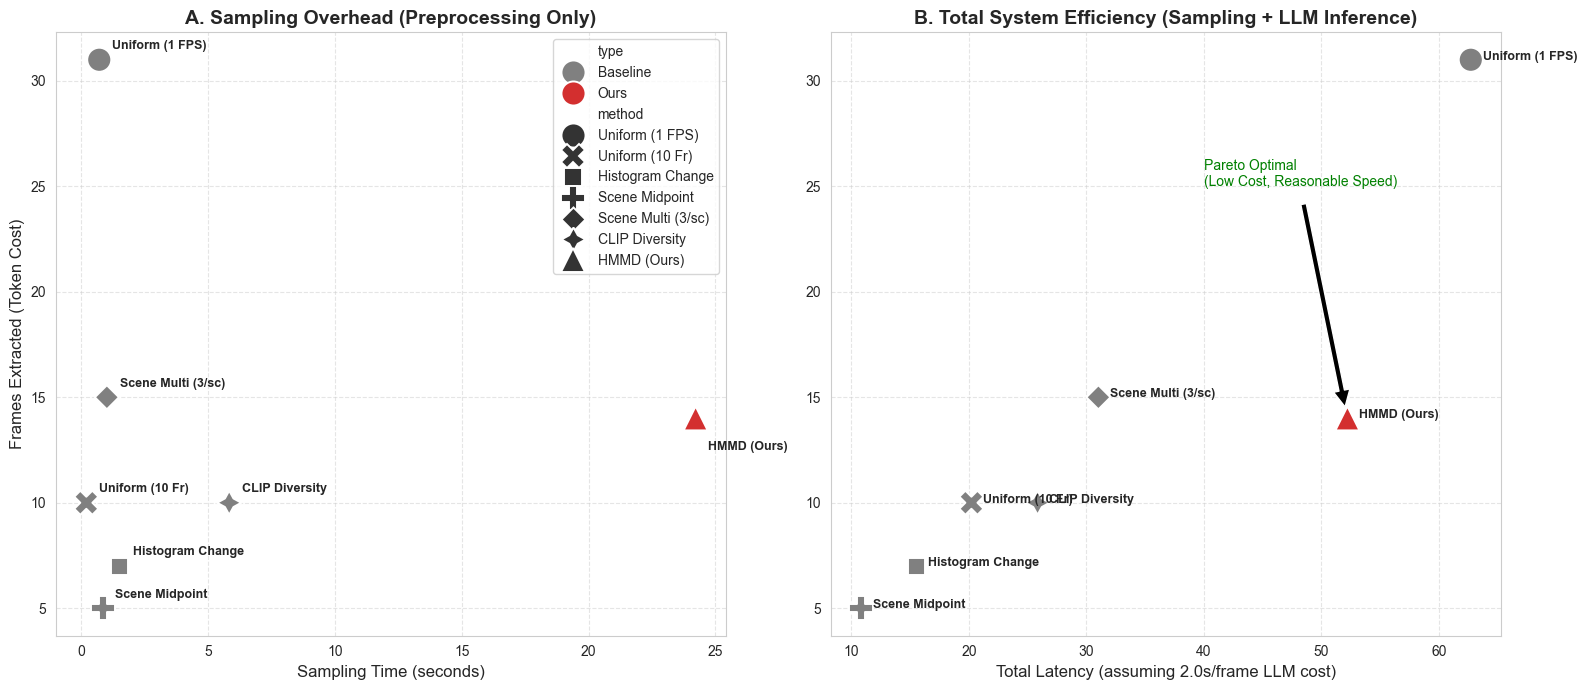

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# ---------------------------------------------------------
# 1. REAL DATA INPUT (From your logs)
# ---------------------------------------------------------
# Scenario: Video '-1yXdOufzKE.mp4' (30.0s duration)
LLM_LATENCY_PER_FRAME = 2.0  # Conservative estimate for Gemini/GPT-4o per-image latency

data = [
    # --- Baselines (From baselines.py output) ---
    {"method": "Uniform (1 FPS)",      "frames": 31, "sampling_time": 0.72,  "type": "Baseline"},
    {"method": "Uniform (10 Fr)",      "frames": 10, "sampling_time": 0.21,  "type": "Baseline"},
    {"method": "Histogram Change",     "frames": 7,  "sampling_time": 1.53,  "type": "Baseline"},
    {"method": "Scene Midpoint",       "frames": 5,  "sampling_time": 0.85,  "type": "Baseline"},
    {"method": "Scene Multi (3/sc)",   "frames": 15, "sampling_time": 1.02,  "type": "Baseline"},
    {"method": "CLIP Diversity",       "frames": 10, "sampling_time": 5.84,  "type": "Baseline"},
    
    # --- HMMD (From hmmd.py log) ---
    # Note: We use the CPU time (24.22s). If you run on GPU, update this to ~14s.
    {"method": "HMMD (Ours)",          "frames": 14, "sampling_time": 24.22, "type": "Ours"}
]

df = pd.DataFrame(data)

# Calculate "Total System Latency"
# This proves that spending time filtering (HMMD) saves time overall
df["total_latency"] = df["sampling_time"] + (df["frames"] * LLM_LATENCY_PER_FRAME)

# ---------------------------------------------------------
# 2. PLOTTING
# ---------------------------------------------------------
sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- PLOT 1: Raw Sampling Efficiency (Engineering View) ---
# This shows HMMD works hard upfront
sns.scatterplot(data=df, x="sampling_time", y="frames", hue="type", style="method", 
                s=300, palette={"Baseline": "grey", "Ours": "#D32F2F"}, ax=ax1)

ax1.set_title("A. Sampling Overhead (Preprocessing Only)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Sampling Time (seconds)", fontsize=12)
ax1.set_ylabel("Frames Extracted (Token Cost)", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

# Annotate Plot 1
for i, row in df.iterrows():
    # Offset labels to avoid overlap
    y_off = 0.5 if row['method'] != "HMMD (Ours)" else -1.5
    ax1.text(row['sampling_time']+0.5, row['frames']+y_off, row['method'], fontsize=9, fontweight='bold')

# --- PLOT 2: Total System Efficiency (Business View) ---
# This shows HMMD wins the race
sns.scatterplot(data=df, x="total_latency", y="frames", hue="type", style="method", 
                s=300, palette={"Baseline": "grey", "Ours": "#D32F2F"}, ax=ax2, legend=False)

ax2.set_title("B. Total System Efficiency (Sampling + LLM Inference)", fontsize=14, fontweight='bold')
ax2.set_xlabel(f"Total Latency (assuming {LLM_LATENCY_PER_FRAME}s/frame LLM cost)", fontsize=12)
ax2.set_ylabel("") # Share Y axis label conceptually
ax2.grid(True, linestyle='--', alpha=0.5)

# Add "Pareto Frontier" curve to Plot 2
# (Highlighting the optimal region towards bottom-left)
ax2.annotate('Pareto Optimal\n(Low Cost, Reasonable Speed)', 
            xy=(df[df['method']=='HMMD (Ours)']['total_latency'], df[df['method']=='HMMD (Ours)']['frames']), 
            xytext=(40, 25),
            arrowprops=dict(facecolor='black', shrink=0.05),
            fontsize=10, color='green')

# Annotate Plot 2
for i, row in df.iterrows():
    ax2.text(row['total_latency']+1, row['frames'], row['method'], fontsize=9, fontweight='bold')

plt.tight_layout()
# plt.savefig("efficiency_frontier_comparison.png", dpi=300)
# print("Chart generated: efficiency_frontier_comparison.png")